In [ ]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

In [ ]:
%load_ext autoreload
%autoreload 2

In [ ]:
!pip install scipy PyWavelets -q

import requests, io
import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import scipy.io as iomat
import helpers
from TIMBRE import TIMBRE
import pywt

# --- Load data ---
url = "https://api.figshare.com/v2/articles/24757638"
files = requests.get(url).json()['files']
f = next(x for x in files if x['name'] == 'data04.mat')
data = iomat.loadmat(io.BytesIO(requests.get(f['download_url']).content))

# --- Preprocess ---
LFPs = helpers.filter_data(data['lfps'], 2, fs=25, use_hilbert=True)
test_inds, train_inds = helpers.test_train(data['lapID'], which_phase=2, n_folds=5, which_fold=0)
wLFPs, U, Xv = helpers.whiten(LFPs, train_inds)
print(f"LFPs shape: {LFPs.shape}, electrodes: {LFPs.shape[1]}")

In [144]:
test_inds_1, train_inds_1 = helpers.test_train(data['lapID'], which_phase=1, n_folds=5, which_fold=0)
wLFPs_1, U_1, Xv_1 = helpers.whiten(LFPs, train_inds_1)
m0,_,_= TIMBRE(wLFPs_1, data['lapID'][:, 1], test_inds_1, train_inds_1, hidden_nodes=0)


In [ ]:
arms = 3
t0 = helpers.get_complex_weights(m0)

for i in range(arms):
    ARM = np.where((data['lapID'][:, 1] == i) & (data['lapID'][:, 3] == 1))[0]
    print(np.mean(np.abs(((LFPs[ARM] @ (np.conj(U_1.T) / Xv_1) @ np.conj(t0)))) ,axis = 0))

In [53]:
m3,_,_= TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=3)
m6,_,_= TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=6)

In [ ]:
t3 = helpers.get_complex_weights(m3, 3)
t6 = helpers.get_complex_weights(m6, 6)

arm_nodes_m3 = helpers.node_arm_map(m3, wLFPs, test_inds, data['lapID'], top_k=1)
arm_nodes_m6 = helpers.node_arm_map(m6, wLFPs, test_inds, data['lapID'], top_k=2)

In [170]:
arms = 3

for i in range(arms):
    ARM = np.where((data['lapID'][:, 1] == i) & (data['lapID'][:, 3] == 2))[0]
    print(np.mean(np.abs((LFPs[ARM] @ np.conj(U.T / Xv) @ t6)) ,axis = 0))

[1.01504123 0.90172775 0.89424587 0.78885839 0.99935886 0.98388837]
[0.93139824 0.91387857 0.89764972 0.80127279 1.01837732 0.96218808]
[0.97229427 0.93121044 0.88661643 0.79008019 0.96790642 0.96455594]


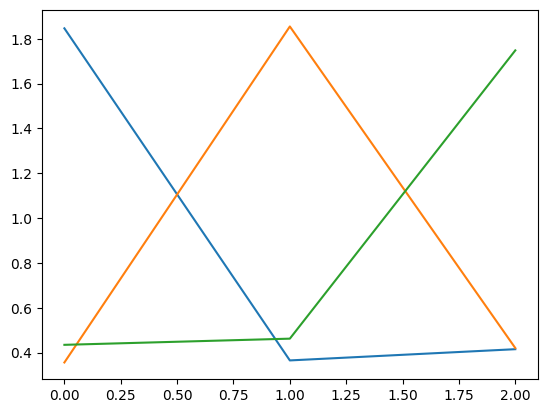

In [165]:
#plt.plot(np.abs(((LFPs[test_inds] @ (np.conj(U.T))/Xv) @ np.conj(t3)) ))
plt.figure()
for i in range(arms):
    ARM = np.where((data['lapID'][:, 1] == i) & (data['lapID'][:, 3] == 1))[0]
    plt.plot(np.mean(np.abs(((LFPs[ARM] @ (np.conj(U_1.T) / Xv_1) @ np.conj(t0)))) ,axis = 0))
plt.show()
#plt.plot(np.abs(LFPs

#(np.conj(U_1.T) / Xv_1) @ np.conj(t0))

In [166]:
#eSpace3 = U @ t3 
#eSpace6 = U @ t6 

eSpace3 = (np.conj(U.T) / Xv) @ np.conj(t3)
eSpace6 = (np.conj(U.T) / Xv) @ np.conj(t6)

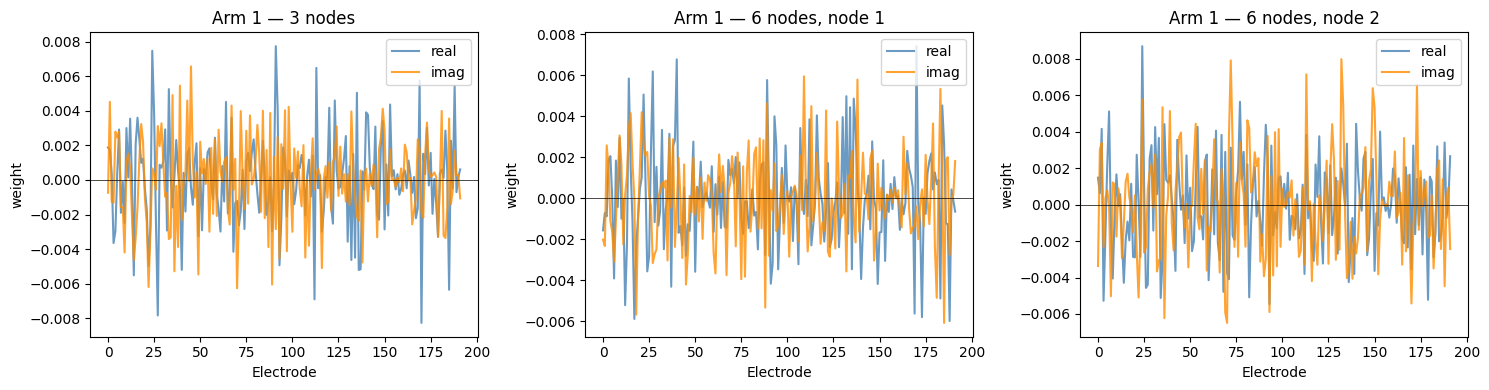

In [167]:
arm_idx = 0  

node3  = arm_nodes_m3[arm_idx][0]
n0, n1 = arm_nodes_m6[arm_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

filters = [
    (eSpace3[:, node3],  f'Arm {arm_idx+1} — 3 nodes'),
    (eSpace6[:, n0],     f'Arm {arm_idx+1} — 6 nodes, node 1'),
    (eSpace6[:, n1],     f'Arm {arm_idx+1} — 6 nodes, node 2'),
]

vmax = max(np.max(np.abs(f)) for f, _ in filters)

for ax, (f, title) in zip(axes, filters):
      ax.plot(f.real, color='steelblue', alpha=0.8, label='real')
      ax.plot(f.imag, color='darkorange', alpha=0.8, label='imag')
      ax.axhline(0, color='k', lw=0.5)
      ax.set_title(title)
      ax.set_xlabel('Electrode')
      ax.set_ylabel('weight')
      ax.legend()

plt.tight_layout()
plt.show()

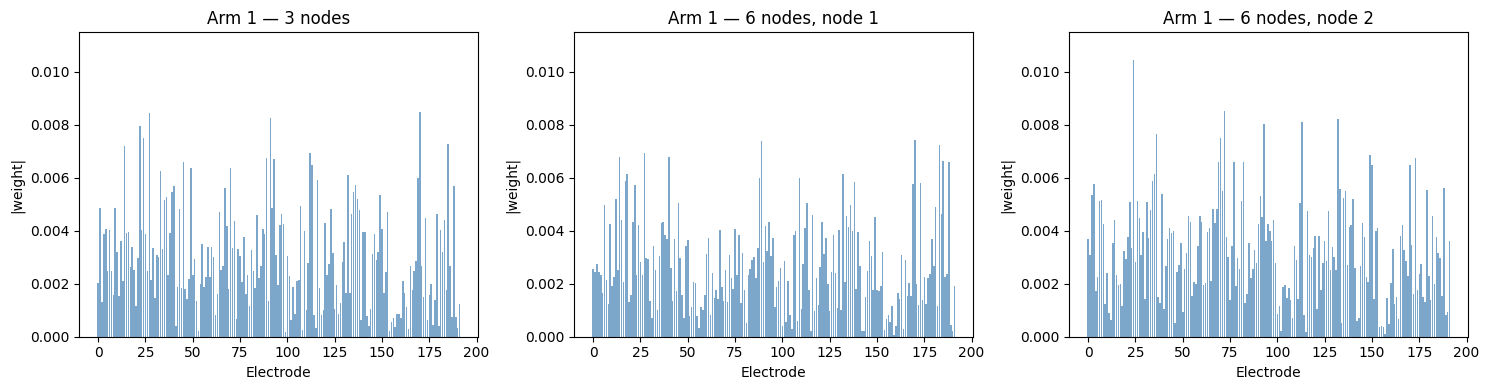

In [168]:
arm_idx = 0  

node3  = arm_nodes_m3[arm_idx][0]
n0, n1 = arm_nodes_m6[arm_idx]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

filters = [
    (eSpace3[:, node3],  f'Arm {arm_idx+1} — 3 nodes'),
    (eSpace6[:, n0],     f'Arm {arm_idx+1} — 6 nodes, node 1'),
    (eSpace6[:, n1],     f'Arm {arm_idx+1} — 6 nodes, node 2'),
]

vmax = max(np.max(np.abs(f)) for f, _ in filters)

for ax, (f, title) in zip(axes, filters):
    ax.bar(range(len(f)), np.abs(f), color='steelblue', alpha=0.7)
    ax.set_ylim(0, vmax * 1.1)
    ax.set_title(title)
    ax.set_xlabel('Electrode')
    ax.set_ylabel('|weight|')

plt.tight_layout()
plt.show()

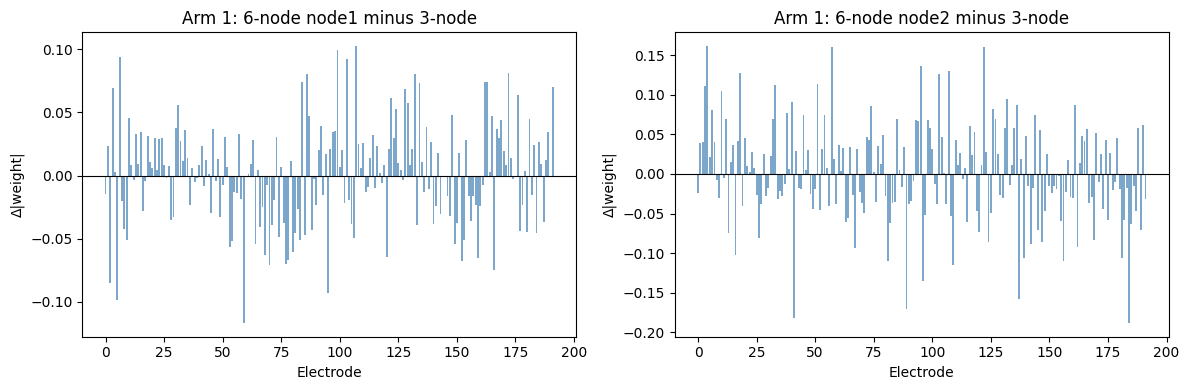

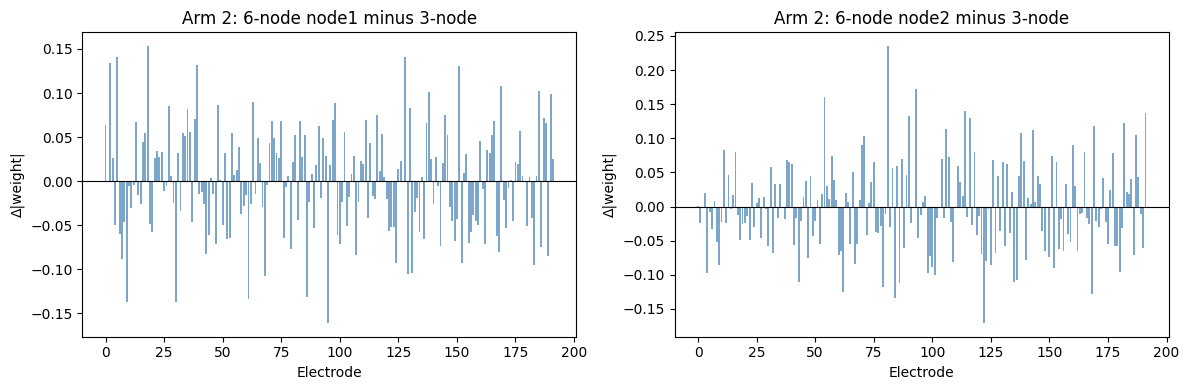

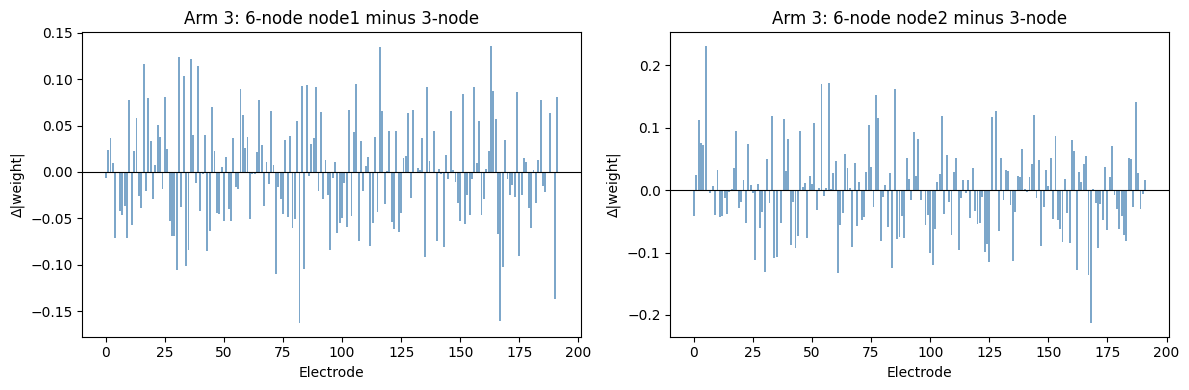

In [78]:
for arm in range(3):
    node3  = arm_nodes_m3[arm][0]
    n0, n1 = arm_nodes_m6[arm]

    f3  = np.abs(u @ t3[:, node3])
    f6a = np.abs(u @ t6[:, n0])
    f6b = np.abs(u @ t6[:, n1])

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(range(192), f6a - f3, color='steelblue', alpha=0.7)
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_title(f'Arm {arm+1}: 6-node node1 minus 3-node')
    axes[0].set_xlabel('Electrode')
    axes[0].set_ylabel('Δ|weight|')

    axes[1].bar(range(192), f6b - f3, color='steelblue', alpha=0.7)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title(f'Arm {arm+1}: 6-node node2 minus 3-node')
    axes[1].set_xlabel('Electrode')
    axes[1].set_ylabel('Δ|weight|')

    plt.tight_layout()
    plt.show()

In [ ]:
#AVERAGEING RUNS

In [ ]:
n_runs = 20

# shape will be (n_runs, 192) per arm
F3_by_arm = [[] for _ in range(3)]
F6_by_arm = [[[], []] for _ in range(3)]   # two nodes per arm

for i in range(n_runs):
    m3_, _, _ = TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=3)
    m6_, _, _ = TIMBRE(wLFPs, data['lapID'][:, 1], test_inds, train_inds, hidden_nodes=6)

    T3_ = helpers.get_complex_weights(m3_, 3)
    T6_ = helpers.get_complex_weights(m6_, 6)
    nodes_m3_ = helpers.node_arm_map(m3_, wLFPs, test_inds, data['lapID'], top_k=1)
    nodes_m6_ = helpers.node_arm_map(m6_, wLFPs, test_inds, data['lapID'], top_k=2)

    eS3_ = np.abs(u @ T3_)
    eS6_ = np.abs(u @ T6_)

    for arm in range(3):
        node3    = nodes_m3_[arm][0]
        n0, n1   = nodes_m6_[arm]
        F3_by_arm[arm].append(eS3_[:, node3])
        F6_by_arm[arm][0].append(eS6_[:, n0])
        F6_by_arm[arm][1].append(eS6_[:, n1])

# average across runs
F3_mean = [np.mean(F3_by_arm[arm], axis=0) for arm in range(3)]
F6_mean = [[np.mean(F6_by_arm[arm][n], axis=0) for n in range(2)] for arm in range(3)]

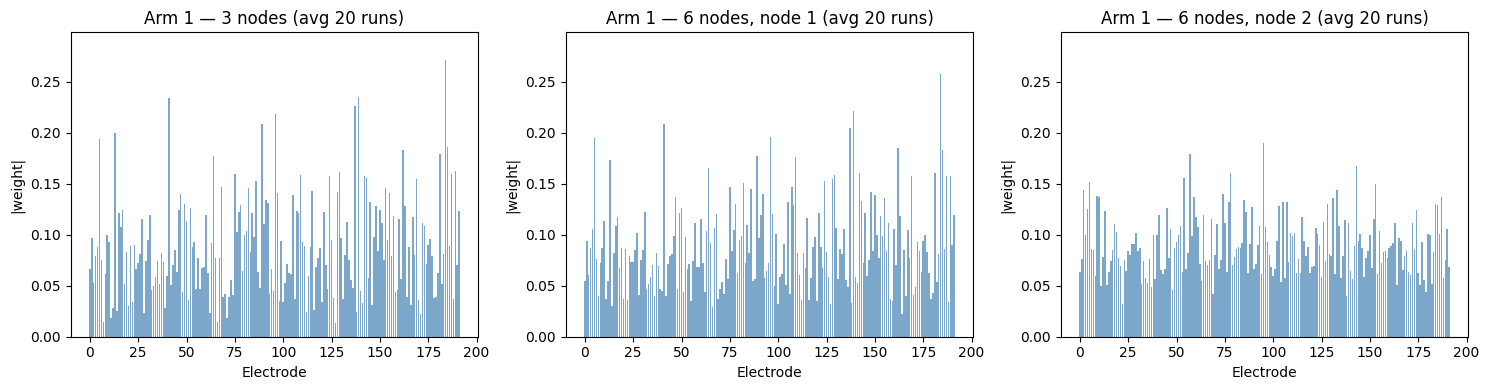

In [74]:
arm = 0   

f3  = F3_mean[arm]
f6a = F6_mean[arm][0]
f6b = F6_mean[arm][1]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

filters = [
        (f3,  f'Arm {arm+1} — 3 nodes (avg {n_runs} runs)'),
        (f6a, f'Arm {arm+1} — 6 nodes, node 1 (avg {n_runs} runs)'),
        (f6b, f'Arm {arm+1} — 6 nodes, node 2 (avg {n_runs} runs)'),
    ]

vmax = max(np.max(np.abs(f)) for f, _ in filters)

for ax, (f, title) in zip(axes, filters):
    ax.bar(range(len(f)), np.abs(f), color='steelblue', alpha=0.7)
    ax.set_ylim(0, vmax * 1.1)
    ax.set_title(title)
    ax.set_xlabel('Electrode')
    ax.set_ylabel('|weight|')

plt.tight_layout()
plt.show()

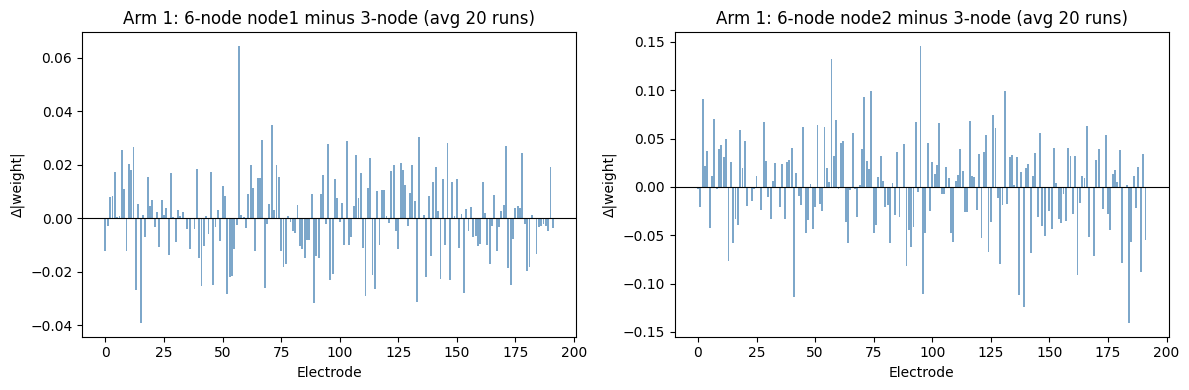

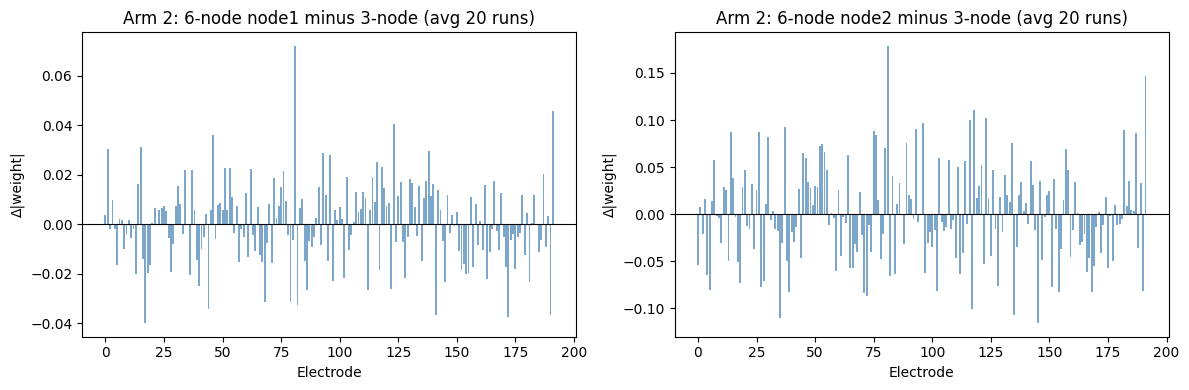

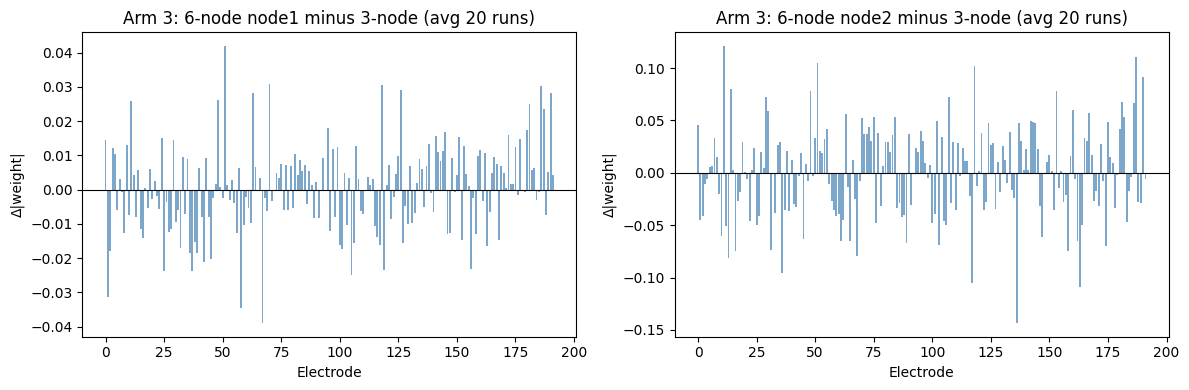

In [62]:
for arm in range(3):
    f3  = F3_mean[arm]
    f6a = F6_mean[arm][0]
    f6b = F6_mean[arm][1]

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))

    axes[0].bar(range(192), f6a - f3, color='steelblue', alpha=0.7)
    axes[0].axhline(0, color='black', linewidth=0.8)
    axes[0].set_title(f'Arm {arm+1}: 6-node node1 minus 3-node (avg {n_runs} runs)')
    axes[0].set_xlabel('Electrode')
    axes[0].set_ylabel('Δ|weight|')

    axes[1].bar(range(192), f6b - f3, color='steelblue', alpha=0.7)
    axes[1].axhline(0, color='black', linewidth=0.8)
    axes[1].set_title(f'Arm {arm+1}: 6-node node2 minus 3-node (avg {n_runs} runs)')
    axes[1].set_xlabel('Electrode')
    axes[1].set_ylabel('Δ|weight|')

    plt.tight_layout()
    plt.show()